# Feature Engineering on the Titanic Dataset
### Student Notebook

Your name: Raghavendra Prasad G Shetti

## Instructions
- This notebook has **8 sections** covering the full feature-engineering workflow.
- Some cells are **pre-filled** — read them carefully before moving on.
- Cells with blanks marked `___` require you to fill in the missing code.
- `# TODO` comments explain exactly what each blank expects.
- Run each cell after completing it to check your output.
- Answer the Exit Question at the end.

Dataset: Titanic (built-in seaborn dataset — no file needed)


---
## 0. Setup & Load Data

In [1]:
# --- Imports ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 4)
print("Imports done")


Imports done


In [2]:
# Load the Titanic dataset from seaborn.
df_raw = sns.load_dataset('titanic')

# TODO: Print the shape of df_raw so you know how many rows and columns there are.
print('Shape:',df_raw.shape)

# Display the first five rows.
df_raw.head()


Shape: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
# Shows column names, non-null counts, and data types.
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [4]:
# Synthetic booking dates — pre-filled, just run this cell.
np.random.seed(42)
base_date = pd.Timestamp('1912-01-01')
random_day_offsets = np.random.randint(0, 100, size=len(df_raw))
random_day_deltas = pd.to_timedelta(random_day_offsets, unit='D')
df_raw['booking_date'] = base_date + random_day_deltas
print('booking_date sample:')
df_raw['booking_date'].head()


booking_date sample:


0   1912-02-21
1   1912-04-02
2   1912-01-15
3   1912-03-12
4   1912-03-01
Name: booking_date, dtype: datetime64[ns]

In [5]:
# Copy raw data so the original is preserved.
df = df_raw.copy()

# These columns are duplicated, mostly empty, or leak the target — drop them.
columns_to_drop = ['deck', 'embark_town', 'alive', 'who', 'adult_male', 'alone']

# TODO: Drop columns_to_drop from df in-place.
df.drop(columns=columns_to_drop, inplace=True)

print('Columns remaining:', df.columns.tolist())


Columns remaining: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'booking_date']


---
## 1. Handling Missing Values

Missing values are a reality in almost every real dataset. Before we can engineer features or train models, we need to decide what to do with them.

**Strategies:**
- **Drop** the column (if >50-70% missing and not recoverable)
- **Statistical imputation** — fill with mean / median / mode
- **KNN imputation** — uses similar rows to estimate the missing value

**Rule:** Always impute *after* the train/test split in a real pipeline. Here we impute on the full dataset for demonstration purposes.


          Missing Count  Missing %
age                 177      19.87
embarked              2       0.22


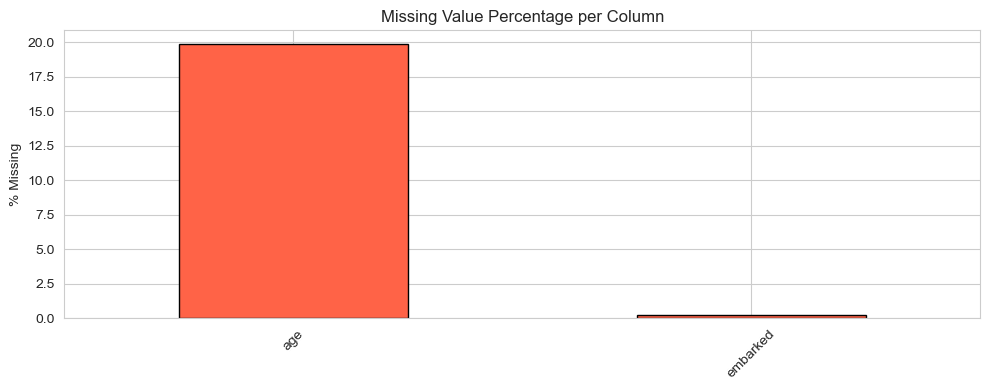

In [6]:
# Count and visualise missing values — pre-filled, read carefully.
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)
print(missing_df)

missing_df['Missing %'].plot(kind='bar', color='tomato', edgecolor='black')
plt.title('Missing Value Percentage per Column')
plt.ylabel('% Missing')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [7]:
print('Age missing before:', df['age'].isnull().sum())

# TODO: Create a SimpleImputer that fills missing age values with the median.
age_imputer = SimpleImputer(strategy='median')

# TODO: Fit and transform the age column, then store the result back in df['age'].
df['age'] = age_imputer.fit_transform(df[['age']])

print('Age missing after :', df['age'].isnull().sum())
print('Median used        :', age_imputer.statistics_[0])


Age missing before: 177
Age missing after : 0
Median used        : 28.0


In [8]:
print('Embarked missing before:', df['embarked'].isnull().sum())

# TODO: Create a SimpleImputer that fills missing embarked values with the most frequent category.
embarked_imputer = SimpleImputer(strategy='most_frequent')

# TODO: Fit and transform the embarked column. Use .ravel() at the end to flatten the result.
df['embarked'] = embarked_imputer.fit_transform(df[['embarked']]).ravel()

print('Embarked missing after :', df['embarked'].isnull().sum())
print('Mode used              :', embarked_imputer.statistics_[0])


Embarked missing before: 2
Embarked missing after : 0
Mode used              : S


In [9]:
# KNN Imputation demo — pre-filled.
# KNNImputer estimates a missing value from the k most similar rows.
df_knn_demo = df[['fare', 'pclass']].copy()
df_knn_demo.loc[0, 'fare'] = np.nan        # artificially introduce a missing value

knn_imputer = KNNImputer(n_neighbors=5)
df_knn_demo_filled_array = knn_imputer.fit_transform(df_knn_demo)
df_knn_demo_filled = pd.DataFrame(df_knn_demo_filled_array, columns=['fare', 'pclass'])

print('KNN-imputed fare for row 0:', round(df_knn_demo_filled.loc[0, 'fare'], 2))
print('(Original value was:', df_raw.loc[0, 'fare'], ')')


KNN-imputed fare for row 0: 9.65
(Original value was: 7.25 )


In [10]:
# TODO: Print the count of remaining missing values in every column of df.
print('Remaining nulls:', df.isnull())


Remaining nulls:      survived  pclass    sex    age  sibsp  parch   fare  embarked  class  \
0       False   False  False  False  False  False  False     False  False   
1       False   False  False  False  False  False  False     False  False   
2       False   False  False  False  False  False  False     False  False   
3       False   False  False  False  False  False  False     False  False   
4       False   False  False  False  False  False  False     False  False   
..        ...     ...    ...    ...    ...    ...    ...       ...    ...   
886     False   False  False  False  False  False  False     False  False   
887     False   False  False  False  False  False  False     False  False   
888     False   False  False  False  False  False  False     False  False   
889     False   False  False  False  False  False  False     False  False   
890     False   False  False  False  False  False  False     False  False   

     booking_date  
0           False  
1           False 

---
## 2. Encoding Categorical Variables

ML algorithms work with numbers. Categorical columns must be converted.

| Encoding | Use when |
|---|---|
| **Label Encoding** | Binary or ordinal categories (female / male) |
| **One-Hot Encoding** | Nominal categories with no natural order (port S / C / Q) |

**Why not Label Encode nominal data?** It creates a false ordering — encoding `S=0, C=1, Q=2` implies Q > C > S, which is meaningless.


In [11]:
# Label encoding for the binary 'sex' column.
le = LabelEncoder()

# TODO: Fit and transform the encoder on df['sex'] and store the result in a new column 'sex_encoded'.
df['sex_encoded'] = le.fit_transform(df['sex'])

print('Mapping:', dict(zip(le.classes_, le.transform(le.classes_))))
df[['sex', 'sex_encoded']].value_counts().reset_index()


Mapping: {'female': 0, 'male': 1}


,sex,sex_encoded,0
0,male,1,577
1,female,0,314


In [12]:
# TODO: Use pd.get_dummies() to one-hot encode df['embarked'].
#       Use prefix='embarked' and drop_first=True to avoid redundant columns.
embarked_dummies = pd.get_dummies(df['embarked'], prefix='embarked', drop_first=True)

print(embarked_dummies.head())

# Attach the new dummy columns to df.
df = pd.concat([df, embarked_dummies], axis=1)


   embarked_Q  embarked_S
0           0           1
1           0           0
2           0           1
3           0           1
4           0           1


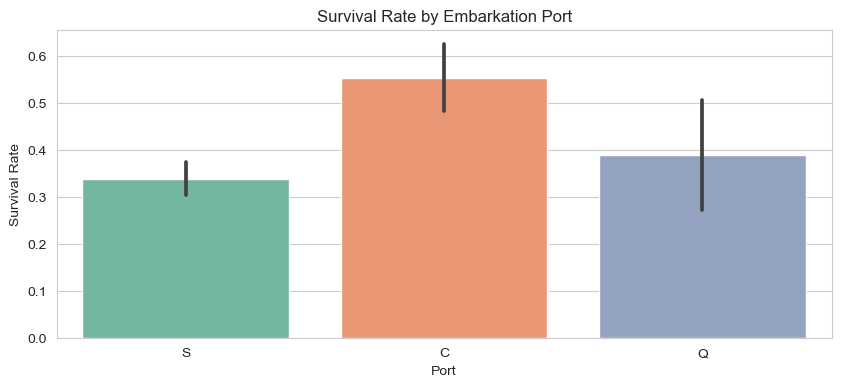

In [13]:
# Bar chart: does embarkation port predict survival? — pre-filled.
sns.barplot(x='embarked', y='survived', data=df, palette='Set2')
plt.title('Survival Rate by Embarkation Port')
plt.ylabel('Survival Rate')
plt.xlabel('Port')
plt.show()


---
## 3. Feature Scaling / Normalization

Many algorithms (SVM, KNN, logistic regression, neural nets) are sensitive to the *scale* of features. A `fare` ranging 0–500 would dominate `age` ranging 0–80 without scaling.

| Scaler | Formula | Best for |
|---|---|---|
| **StandardScaler** | (x − mean) / std | Normally distributed data; most algorithms |
| **MinMaxScaler** | (x − min) / (max − min) | Neural networks; bounded output needed |


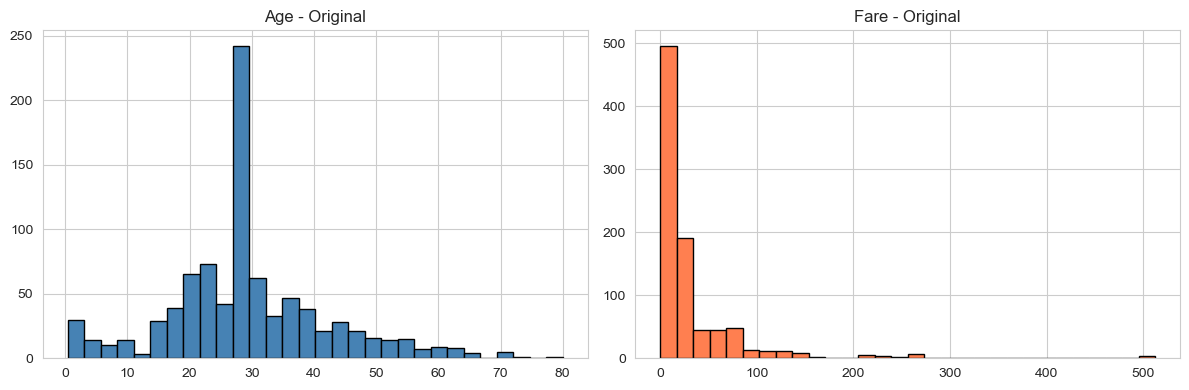

In [14]:
# Visualise the raw distributions before scaling — pre-filled.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['age'].hist(ax=axes[0], bins=30, color='steelblue', edgecolor='black')
axes[0].set_title('Age - Original')
df['fare'].hist(ax=axes[1], bins=30, color='coral', edgecolor='black')
axes[1].set_title('Fare - Original')
plt.tight_layout()
plt.show()


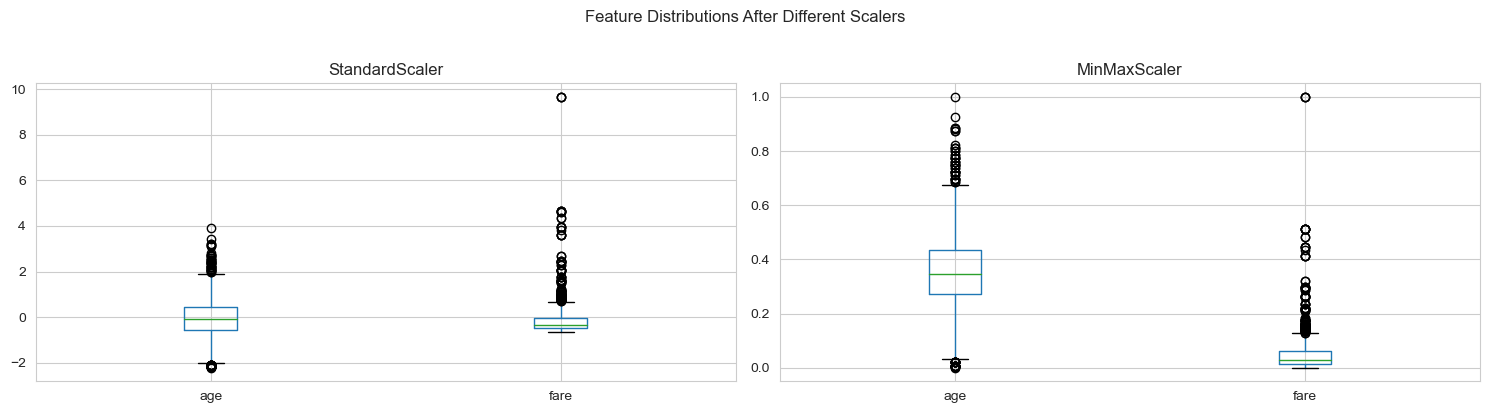

In [15]:
# Compare StandardScaler vs MinMaxScaler side by side — pre-filled.
# Read the loop carefully; you'll write something similar in Section 8.
numeric_cols = ['age', 'fare']

scalers = {
    'StandardScaler': StandardScaler(),
    'MinMaxScaler':   MinMaxScaler(),
}

fig, axes = plt.subplots(1, 2, figsize=(15, 4))
for ax, (name, scaler) in zip(axes, scalers.items()):
    scaled = scaler.fit_transform(df[numeric_cols])
    scaled_df = pd.DataFrame(scaled, columns=numeric_cols)
    scaled_df.boxplot(ax=ax)
    ax.set_title(name)
plt.suptitle('Feature Distributions After Different Scalers', y=1.02)
plt.tight_layout()
plt.show()


In [16]:
# Apply StandardScaler and save the scaled columns.
scaler = StandardScaler()

# TODO: Fit and transform df[['age', 'fare']]; store results in 'age_scaled' and 'fare_scaled'.
df[['age_scaled', 'fare_scaled']] = scaler.fit_transform(df[['age', 'fare']])

# After scaling, mean should be ~0 and std should be ~1 for each column.
print('age_scaled  - mean: {:.4f}, std: {:.4f}'.format(df['age_scaled'].mean(), df['age_scaled'].std()))
print('fare_scaled - mean: {:.4f}, std: {:.4f}'.format(df['fare_scaled'].mean(), df['fare_scaled'].std()))


age_scaled  - mean: 0.0000, std: 1.0006
fare_scaled - mean: 0.0000, std: 1.0006


---
## 4. Creating New Features (Domain Knowledge)

Feature engineering at its most creative — using domain understanding to **construct new signals** from existing columns. A good engineered feature can matter more than which algorithm you pick.

For Titanic, we know from history:
- "Women and children first" → `sex` and `age` are important signals
- Larger families may have struggled to evacuate together
- Titles from names reflect social class and gender simultaneously


In [17]:
# Family size = siblings/spouses + parents/children + the passenger themselves.
# TODO: Calculate family_size and store it in df['family_size'].
df['family_size'] = df['sibsp'] + df['parch'] + 1

# TODO: Create is_alone: 1 if the passenger is travelling alone, 0 otherwise.
#       Hint: a passenger is alone when family_size == 1.
df['is_alone'] = (df['family_size'] == 1).astype(int)

print(df[['sibsp', 'parch', 'family_size', 'is_alone']].head(8))


   sibsp  parch  family_size  is_alone
0      1      0            2         0
1      1      0            2         0
2      0      0            1         1
3      1      0            2         0
4      0      0            1         1
5      0      0            1         1
6      0      0            1         1
7      3      1            5         0


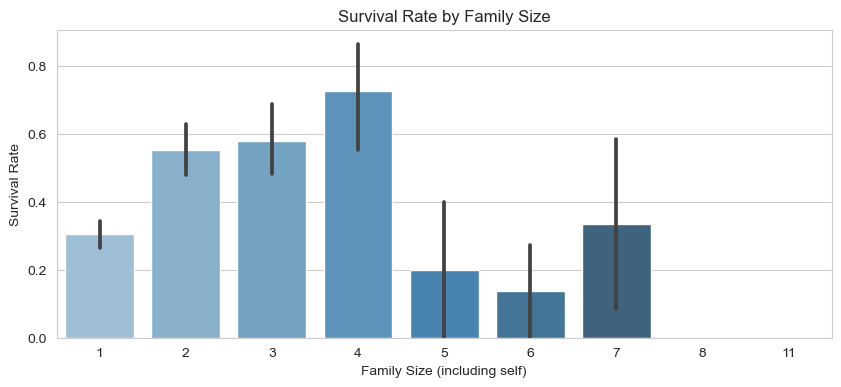

In [18]:
# Bar chart: family size vs survival — pre-filled.
sns.barplot(x='family_size', y='survived', data=df, palette='Blues_d')
plt.title('Survival Rate by Family Size')
plt.xlabel('Family Size (including self)')
plt.ylabel('Survival Rate')
plt.show()


In [19]:
# TODO: Create fare_per_person by dividing fare by family_size.
df['fare_per_person'] = df['fare']/ df['family_size']

print(df[['fare', 'family_size', 'fare_per_person']].head())


      fare  family_size  fare_per_person
0   7.2500            2          3.62500
1  71.2833            2         35.64165
2   7.9250            1          7.92500
3  53.1000            2         26.55000
4   8.0500            1          8.05000


In [20]:
# TODO: Create is_child: 1 if the passenger is under 16, 0 otherwise.
df['is_child'] = (df['age'] < 16).astype(int)

print('Children in dataset:', df['is_child'].sum())
print('Child survival rate :', df[df['is_child'] == 1]['survived'].mean().round(3))
print('Adult survival rate :', df[df['is_child'] == 0]['survived'].mean().round(3))


Children in dataset: 83
Child survival rate : 0.59
Adult survival rate : 0.363


---
## 5. Date / Time Features

Datetime columns carry rich signals that are invisible unless you extract them — day of week, month, hour, time since an event, etc.

We use the synthetic `booking_date` column added in Section 0.


In [21]:
# Convert booking_date to pandas datetime so .dt accessors work.
df['booking_date'] = pd.to_datetime(df['booking_date'])
print(df['booking_date'].dtype)
print(df['booking_date'].head())


datetime64[ns]
0   1912-02-21
1   1912-04-02
2   1912-01-15
3   1912-03-12
4   1912-03-01
Name: booking_date, dtype: datetime64[ns]


In [22]:
# Extract useful date parts from booking_date.

# TODO: Extract the calendar month number.
df['booking_month'] = df['booking_date'].dt.month

# TODO: Extract the day of week (Monday=0, Sunday=6).
df['booking_day_of_week'] = df['booking_date'].dt.dayofweek

# Extract day of the month — pre-filled.
df['booking_day'] = df['booking_date'].dt.day

# TODO: Create is_weekend_booking: 1 for Saturday (5) or Sunday (6), 0 otherwise.
df['is_weekend_booking'] = df['booking_day_of_week'].isin([5, 6]).astype(int)

# Days before the Titanic sailed.
ship_departure = pd.Timestamp('1912-04-15')
df['days_before_departure'] = (ship_departure - df['booking_date']).dt.days

df[['booking_date', 'booking_month', 'booking_day_of_week', 'is_weekend_booking', 'days_before_departure']].head()


,booking_date,booking_month,booking_day_of_week,is_weekend_booking,days_before_departure
0,1912-02-21,2,2,0,54
1,1912-04-02,4,1,0,13
2,1912-01-15,1,0,0,91
3,1912-03-12,3,1,0,34
4,1912-03-01,3,4,0,45


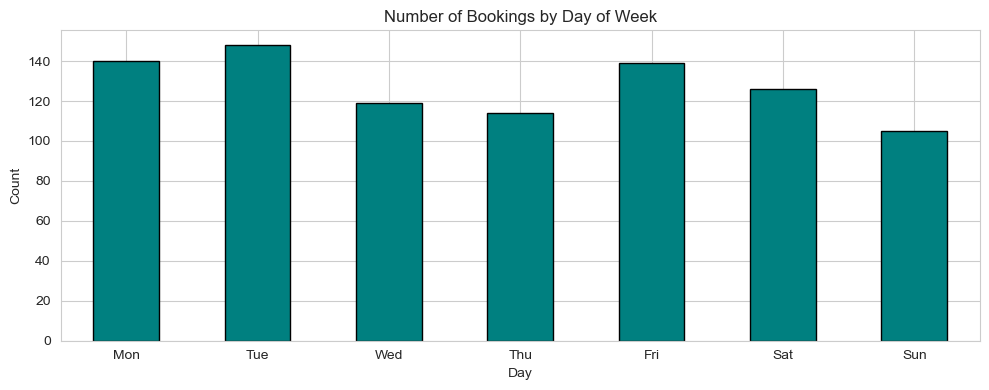

In [23]:
# Bar chart: bookings per day of week — pre-filled.
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
df['booking_day_of_week'].value_counts().sort_index().plot(kind='bar', color='teal', edgecolor='black')
plt.xticks(ticks=range(7), labels=day_names, rotation=0)
plt.title('Number of Bookings by Day of Week')
plt.xlabel('Day')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


---
## 6. Handling Outliers

Outliers can distort model training — particularly distance-based and regression models. We must first **detect** them, then decide whether to **remove** or **cap** them.

**Detection methods:**
- **IQR rule:** values below Q1 − 1.5×IQR or above Q3 + 1.5×IQR
- **Z-score:** values more than 3 standard deviations from the mean

**Treatment options:**
- **Clipping (Winsorizing):** replace extreme values with the boundary value
- **Log transform:** compresses the scale of right-skewed distributions
- **Drop:** only if the value is clearly erroneous (e.g. age = 800)


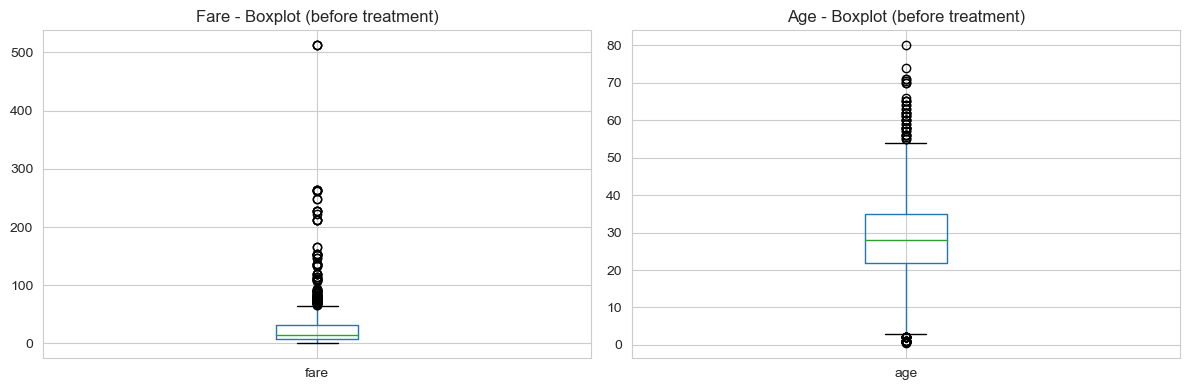

In [24]:
# Boxplots to spot outliers visually — pre-filled.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df.boxplot(column='fare', ax=axes[0])
axes[0].set_title('Fare - Boxplot (before treatment)')
df.boxplot(column='age', ax=axes[1])
axes[1].set_title('Age - Boxplot (before treatment)')
plt.tight_layout()
plt.show()


In [25]:
# IQR outlier detection for fare.

# TODO: Calculate Q1 (25th percentile) and Q3 (75th percentile) of df['fare'].
Q1 = df['fare'].quantile(0.25)
Q3 = df['fare'].quantile(0.75)

# TODO: Calculate the Interquartile Range.
IQR = Q3 - Q1

# TODO: Define the lower and upper outlier boundaries.
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Select rows that fall outside the IQR boundaries.
outliers = df[(df['fare'] < lower_bound) | (df['fare'] > upper_bound)]

print(f'Q1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f}')
print(f'Lower bound: {lower_bound:.2f}, Upper bound: {upper_bound:.2f}')
print(f'Number of outliers detected: {len(outliers)} ({len(outliers)/len(df)*100:.1f}%)')


Q1=7.91, Q3=31.00, IQR=23.09
Lower bound: -26.72, Upper bound: 65.63
Number of outliers detected: 116 (13.0%)


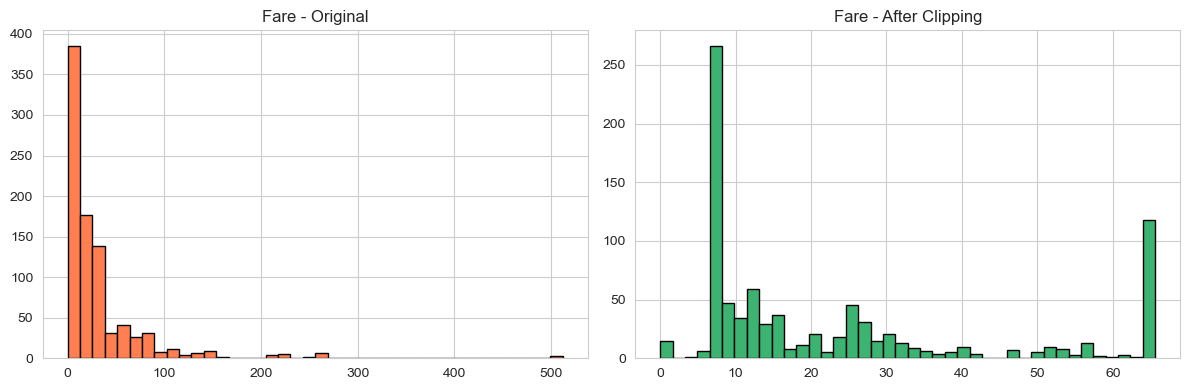

In [26]:
# Clipping (Winsorizing): cap extreme fares at the IQR boundaries.

# TODO: Use .clip() to create fare_clipped, capping values at lower_bound and upper_bound.
df['fare_clipped'] = df['fare'].clip(lower=lower_bound, upper=upper_bound)

# Histograms: original vs clipped — pre-filled.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['fare'].hist(bins=40, ax=axes[0], color='coral', edgecolor='black')
axes[0].set_title('Fare - Original')
df['fare_clipped'].hist(bins=40, ax=axes[1], color='mediumseagreen', edgecolor='black')
axes[1].set_title('Fare - After Clipping')
plt.tight_layout()
plt.show()


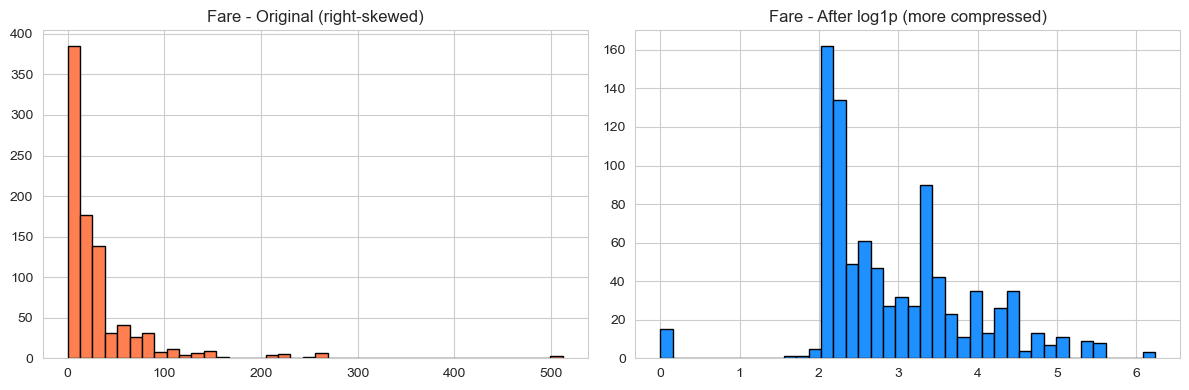

In [27]:
# Log transform: compresses right-skewed distributions.
# np.log1p(x) computes log(1 + x) so zero values are handled safely.

# TODO: Apply np.log1p to df['fare'] and store the result in df['fare_log'].
df['fare_log'] = np.log1p(df['fare'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['fare'].hist(bins=40, ax=axes[0], color='coral', edgecolor='black')
axes[0].set_title('Fare - Original (right-skewed)')
df['fare_log'].hist(bins=40, ax=axes[1], color='dodgerblue', edgecolor='black')
axes[1].set_title('Fare - After log1p (more compressed)')
plt.tight_layout()
plt.show()


In [28]:
# Z-score method for detecting outliers.
from scipy import stats

# TODO: Calculate absolute z-scores for df['fare'].
z_scores = np.abs(stats.zscore(df['fare']))

# TODO: Select rows whose fare z-score exceeds 3 (a common threshold).
z_outliers = df[z_scores > 3]

print(f'Outliers by Z-score (|z| > 3): {len(z_outliers)}')


Outliers by Z-score (|z| > 3): 20


---
## 7. Binning / Discretization

Sometimes converting a continuous variable into **categories (bins)** is more informative — e.g. age groups carry more meaning than exact ages for survival analysis.

| Method | How it divides | Use when |
|---|---|---|
| `pd.cut` | Equal-width intervals | Uniform distribution |
| `pd.qcut` | Equal-frequency (quantile) bins | Skewed distribution |
| `KBinsDiscretizer` | sklearn-compatible binning | Inside a Pipeline |


In [29]:
# pd.cut: fixed-width bins defined by domain knowledge.

# TODO: Use pd.cut to create an 'age_bin' column with these boundaries and labels.
df['age_bin'] = pd.cut(
    df['age'],
    bins=[0, 12, 18, 35, 60, 80],          # TODO: fill the first and last boundary
    labels=['Child', 'Teen', 'YoungAdult', 'Adult', 'Senior']
)

print(df['age_bin'].value_counts().sort_index())


Child          69
Teen           70
YoungAdult    535
Adult         195
Senior         22
Name: age_bin, dtype: int64


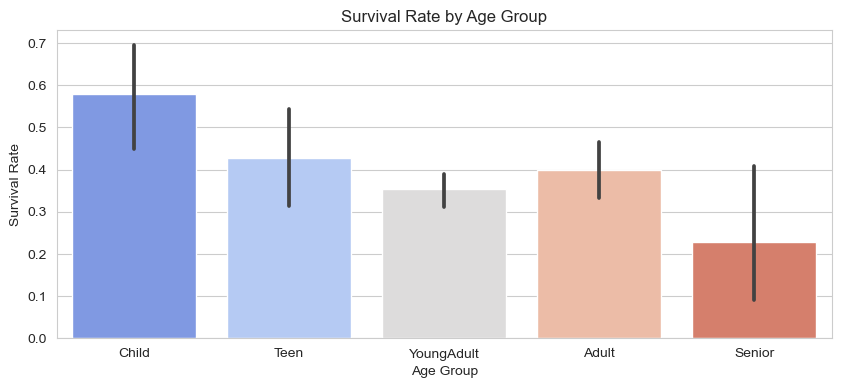

In [30]:
# Bar chart: age group vs survival — pre-filled.
age_order = ['Child', 'Teen', 'YoungAdult', 'Adult', 'Senior']
sns.barplot(x='age_bin', y='survived', data=df, order=age_order, palette='coolwarm')
plt.title('Survival Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Survival Rate')
plt.show()


In [31]:
# pd.qcut: quantile bins — roughly equal passenger counts in each bin.

# TODO: Use pd.qcut to split fare into 4 equal-frequency bins with the labels below.
df['fare_bin'] = pd.qcut(df['fare'], q=4, labels=['Q1_Low', 'Q2_Mid', 'Q3_High', 'Q4_VeryHigh'])

print(df['fare_bin'].value_counts().sort_index())


Q1_Low         223
Q2_Mid         224
Q3_High        222
Q4_VeryHigh    222
Name: fare_bin, dtype: int64


In [32]:
# sklearn KBinsDiscretizer — works inside a Pipeline unlike pd.cut/pd.qcut.
from sklearn.preprocessing import KBinsDiscretizer

# Creates 4 quantile-based bins and encodes each as an ordinal number (0, 1, 2, 3).
kbd = KBinsDiscretizer(n_bins=4, encode='ordinal', strategy='quantile')

# TODO: Fit and transform df[['fare']], then flatten with .ravel() and store in df['fare_bin_sklearn'].
df['fare_bin_sklearn'] = kbd.fit_transform(df[['fare']]).ravel()

print('KBinsDiscretizer fare bins:')
print(df['fare_bin_sklearn'].value_counts().sort_index())


KBinsDiscretizer fare bins:
0.0    223
1.0    217
2.0    226
3.0    225
Name: fare_bin_sklearn, dtype: int64


---
## 8. Putting It All Together: A Feature Engineering Pipeline

A `Pipeline` chains all preprocessing steps into a single object. Key benefits:
- **No data leakage** — `fit` only on training data, `transform` on test
- **Reproducibility** — same steps applied consistently every time
- **Production-ready** — you can save and reload the whole pipeline

We use `ColumnTransformer` to apply different steps to different column types.


In [33]:
from sklearn.model_selection import train_test_split

# Fresh copy using only the relevant columns.
df_pipe = df_raw[['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'survived']].copy()

# TODO: Create feature matrix X by dropping the 'survived' column.
X = df_pipe.drop(columns='survived')

# TODO: Create the target vector y from the 'survived' column.
y = df_pipe['survived']

# Split before fitting any preprocessor to avoid data leakage.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Train size:', X_train.shape, '  Test size:', X_test.shape)


Train size: (712, 7)   Test size: (179, 7)


In [38]:
# Define column groups — pre-filled.
numeric_features     = ['age', 'fare', 'sibsp', 'parch']
categorical_features = ['sex', 'embarked']
passthrough_features = ['pclass']

# TODO: Build the numeric pipeline: median imputation → StandardScaler.
numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

# Version-compatible OneHotEncoder — pre-filled.
try:
    onehot_encoder = OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False)
except TypeError:
    onehot_encoder = OneHotEncoder(handle_unknown='ignore', drop='first', sparse=False)

# TODO: Build the categorical pipeline: most_frequent imputation → OneHotEncoder.
categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', onehot_encoder)
])

# Combine everything in a ColumnTransformer — pre-filled.
preprocessor = ColumnTransformer(transformers=[
    ('num',  numeric_pipeline,     numeric_features),
    ('cat',  categorical_pipeline, categorical_features),
    ('pass', 'passthrough',        passthrough_features)
])

print('Pipeline defined successfully.')


Pipeline defined successfully.


In [39]:
# TODO: Fit the preprocessor on X_train only, then transform both X_train and X_test.
preprocessor.fit(X_train)
X_train_processed = preprocessor.transform(X_train)
X_test_processed  = preprocessor.transform(X_test)

print('X_train processed shape:', X_train_processed.shape)
print('X_test  processed shape:', X_test_processed.shape)


X_train processed shape: (712, 8)
X_test  processed shape: (179, 8)


In [40]:
# Inspect feature names — pre-filled.
ohe_cols = preprocessor.named_transformers_['cat']['encoder'].get_feature_names_out(categorical_features).tolist()
all_cols = numeric_features + ohe_cols + passthrough_features

X_train_df = pd.DataFrame(X_train_processed, columns=all_cols)
print('Processed training features:')
X_train_df.head()


Processed training features:


,age,fare,sibsp,parch,sex_male,embarked_Q,embarked_S,pclass
0,-0.081135,0.513812,-0.465084,-0.466183,1.0,0.0,1.0,3.0
1,-0.081135,-0.662563,-0.465084,-0.466183,1.0,0.0,1.0,2.0
2,-0.081135,3.955399,-0.465084,-0.466183,1.0,0.0,1.0,1.0
3,-0.887827,-0.467874,-0.465084,0.727782,0.0,0.0,1.0,3.0
4,0.110934,-0.115977,0.478335,0.727782,0.0,0.0,1.0,2.0


In [41]:
# Verify no missing values remain after pipeline processing.
print('Missing in processed train:', pd.DataFrame(X_train_processed).isnull().sum().sum())
print('Missing in processed test :', pd.DataFrame(X_test_processed).isnull().sum().sum())
print()
print('--- Pipeline is ready. X_train_processed can now be passed to any ML model. ---')


Missing in processed train: 0
Missing in processed test : 0

--- Pipeline is ready. X_train_processed can now be passed to any ML model. ---


---
## Summary: What We Did

| Step | Technique | Column(s) |
|---|---|---|
| Missing values | Median imputation | `age` |
| Missing values | Mode imputation | `embarked` |
| Missing values | KNN imputation (demo) | `fare` |
| Encoding | Label Encoding | `sex` |
| Encoding | One-Hot Encoding | `embarked` |
| Scaling | StandardScaler | `age`, `fare` |
| New features | `family_size`, `is_alone`, `is_child` | `sibsp`, `parch`, `age` |
| New features | `fare_per_person` | `fare`, `family_size` |
| Datetime | Month, day-of-week, days before departure | `booking_date` |
| Outliers | IQR detection + clipping + log transform | `fare` |
| Binning | `pd.cut` (equal-width), `pd.qcut` (quantile) | `age`, `fare` |
| Pipeline | `ColumnTransformer` + `Pipeline` | All features |

> The processed output `X_train_processed` and `X_test_processed` are now clean, encoded, and scaled — ready for any ML model in the next lab.


## Exit Question

**Which step in this lab do you think would hurt model performance the most if we skipped it, and why?**

Your answer:
>I think that the Pipeline part is the crusial in this , since it would hurt the model performance the most if we skipped it because ,it ensures missing values are handeled , categorical data is encoded properly and numarical features is scaled properly
and consistently for both training and testing data.Without it the model may recive incomplete or inconsistent data , leading to lower accuracy and unreliable predictions.

---
## Functions, Methods, Attributes, and Parameters Used in This Lab

This section is a quick reference for every important function, method, attribute, and parameter used in the feature engineering lab.

---

### pandas

**pd.DataFrame()**
```python
pd.DataFrame(data, columns=None)
```
Creates a labelled table from a dictionary, array, or other tabular data. Used to build summary tables and convert transformed arrays back into readable tables.

**pd.Timestamp()**
```python
pd.Timestamp('1912-01-01')
```
Creates a pandas datetime object. Used for the synthetic booking-date example.

**pd.to_timedelta()**
```python
pd.to_timedelta(values, unit='D')
```
Converts numbers into time durations. `unit='D'` means the numbers are interpreted as days.

**pd.to_datetime()**
```python
pd.to_datetime(series)
```
Converts a column into datetime format so `.dt` date attributes can be used.

**pd.get_dummies()**
```python
pd.get_dummies(series, prefix='embarked', drop_first=True)
```
Creates one-hot encoded columns. `drop_first=True` removes the first category column to avoid redundant dummy columns.

**pd.concat()**
```python
pd.concat([df, new_columns], axis=1)
```
Combines DataFrames. `axis=1` means combine side by side as columns.

**pd.cut()**
```python
pd.cut(series, bins=[...], labels=[...])
```
Creates fixed-width or manually defined bins. Used to create age groups.

**pd.qcut()**
```python
pd.qcut(series, q=4, labels=[...])
```
Creates quantile bins with roughly equal numbers of rows in each bin. Used for fare quartiles.

**DataFrame.copy()**
```python
df.copy()
```
Creates a separate copy so changes do not affect the original DataFrame.

**DataFrame.drop()**
```python
df.drop(columns=[...], inplace=True)
```
Removes columns or rows. `columns=[...]` removes named columns. `inplace=True` modifies the existing DataFrame.

**DataFrame.info()**
```python
df.info()
```
Shows column names, non-null counts, data types, and memory usage.

**DataFrame.head()**
```python
df.head()
```
Shows the first five rows by default.

**DataFrame.isnull()**
```python
df.isnull()
```
Returns True where values are missing.

**DataFrame.sum()**
```python
df.isnull().sum()
```
Counts True values when used after `isnull()`.

**DataFrame.sort_values()**
```python
df.sort_values('Missing %', ascending=False)
```
Sorts a DataFrame by a column.

**Series.value_counts()**
```python
series.value_counts()
```
Counts how often each unique value appears.

**Series.sort_index()**
```python
series.value_counts().sort_index()
```
Sorts output by index values instead of counts.

**Series.quantile()**
```python
series.quantile(0.25)
```
Returns a percentile. `0.25` is Q1 and `0.75` is Q3.

**Series.clip()**
```python
series.clip(lower=lower_bound, upper=upper_bound)
```
Caps values below the lower boundary and above the upper boundary. Used for outlier treatment.

**Series.hist()**
```python
series.hist(bins=40, ax=axes[0])
```
Plots a histogram of a numerical column.

**DataFrame.boxplot()**
```python
df.boxplot(column='fare', ax=axes[0])
```
Plots a boxplot to show median, quartiles, whiskers, and possible outliers.

**Series.astype()**
```python
condition.astype(int)
```
Converts True/False values into 1/0 values.

**Series.round()**
```python
series.mean().round(3)
```
Rounds numerical output to a chosen number of decimal places.

**Series.ravel()**
```python
array_or_series.ravel()
```
Flattens a 2D result into a 1D array. Used after some sklearn transformations.

**Series.dt.month, .dt.dayofweek, .dt.day, .dt.days**
```python
df['booking_date'].dt.month
```
Extracts date parts from datetime columns.

**Series.isin()**
```python
series.isin([5, 6])
```
Checks whether each value is in a list. Used to identify weekend bookings.

**DataFrame.shape**
```python
df.shape
```
Returns `(number_of_rows, number_of_columns)`.

**DataFrame.columns**
```python
df.columns.tolist()
```
Stores or displays column names.

---

### numpy

**np.random.seed()**
```python
np.random.seed(42)
```
Makes random output reproducible.

**np.random.randint()**
```python
np.random.randint(0, 100, size=len(df_raw))
```
Generates random integers. Used to make synthetic day offsets.

**np.nan**
```python
np.nan
```
Represents a missing numerical value.

**np.log1p()**
```python
np.log1p(series)
```
Computes `log(1 + x)`. Useful when values may include 0.

**np.abs()**
```python
np.abs(values)
```
Returns absolute values. Used to convert negative z-scores into positive distance-from-mean values.

---

### matplotlib.pyplot

**plt.subplots()**
```python
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
```
Creates one or more plot areas. Returns the overall figure and the axes objects.

**plt.title()**
```python
plt.title('Title')
```
Adds a title to the active plot.

**plt.xlabel() and plt.ylabel()**
```python
plt.xlabel('Age Group')
plt.ylabel('Survival Rate')
```
Adds axis labels.

**plt.xticks()**
```python
plt.xticks(rotation=45)
```
Controls x-axis tick labels and rotation.

**plt.suptitle()**
```python
plt.suptitle('Main Title', y=1.02)
```
Adds one title for the whole figure.

**plt.tight_layout()**
```python
plt.tight_layout()
```
Adjusts spacing to reduce overlap between titles, labels, and plots.

**plt.show()**
```python
plt.show()
```
Displays the plot output.

**plt.rcParams**
```python
plt.rcParams['figure.figsize'] = (10, 4)
```
Changes default matplotlib settings.

---

### seaborn

**sns.load_dataset()**
```python
sns.load_dataset('titanic')
```
Loads a built-in seaborn example dataset.

**sns.set_style()**
```python
sns.set_style('whitegrid')
```
Sets the visual background style for seaborn and matplotlib plots.

**sns.barplot()**
```python
sns.barplot(x='embarked', y='survived', data=df)
```
Plots the average value of `y` for each category in `x`. Used for survival-rate comparisons.

---

### sklearn.impute

**SimpleImputer()**
```python
SimpleImputer(strategy='median')
SimpleImputer(strategy='most_frequent')
```
Fills missing values using a simple rule. `median` is common for numeric columns with skew or outliers. `most_frequent` is common for categorical columns.

**KNNImputer()**
```python
KNNImputer(n_neighbors=5)
```
Fills missing values using similar rows. `n_neighbors=5` means five nearby rows are used.

**fit_transform()**
```python
imputer.fit_transform(df[['age']])
```
Learns the imputation value from the data and immediately applies it.

**transform()**
```python
preprocessor.transform(X_test)
```
Applies already-learned preprocessing rules to new data.

**statistics_**
```python
age_imputer.statistics_[0]
```
Stores the learned imputation value, such as the median or mode.

---

### sklearn.preprocessing

**LabelEncoder()**
```python
le = LabelEncoder()
```
Converts categories into integer labels. Used here for a binary column demonstration.

**classes_**
```python
le.classes_
```
Stores the categories learned by `LabelEncoder`.

**OneHotEncoder()**
```python
OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False)
```
Creates one-hot encoded columns inside a pipeline.

Important parameters:
- `handle_unknown='ignore'`: avoids errors if test data contains a category not seen during training.
- `drop='first'`: drops the first category to avoid redundant dummy columns.
- `sparse_output=False`: returns a normal dense array in newer sklearn versions.
- `sparse=False`: older sklearn version of the same dense-output idea.

**get_feature_names_out()**
```python
encoder.get_feature_names_out(categorical_features)
```
Returns names of one-hot encoded columns.

**StandardScaler()**
```python
StandardScaler()
```
Scales values using `(x - mean) / standard deviation`.

**MinMaxScaler()**
```python
MinMaxScaler()
```
Scales values using `(x - min) / (max - min)`, usually into the range 0 to 1.

**RobustScaler()**
```python
RobustScaler()
```
Scales values using median and IQR. Useful when outliers are present.

**KBinsDiscretizer()**
```python
KBinsDiscretizer(n_bins=4, encode='ordinal', strategy='quantile')
```
Creates numerical bins in sklearn style.

Important parameters:
- `n_bins=4`: creates four bins.
- `encode='ordinal'`: returns bin numbers such as 0, 1, 2, 3.
- `strategy='quantile'`: creates bins with roughly equal counts.

---

### sklearn.model_selection

**train_test_split()**
```python
train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
```
Splits data into train and test sets.

Important parameters:
- `test_size=0.2`: puts 20 percent of rows in the test set.
- `random_state=42`: makes the split reproducible.
- `stratify=y`: keeps the class proportion similar in train and test.

---

### sklearn.pipeline and sklearn.compose

**Pipeline()**
```python
Pipeline(steps=[('imputer', SimpleImputer()), ('scaler', StandardScaler())])
```
Chains preprocessing steps in order.

**ColumnTransformer()**
```python
ColumnTransformer(transformers=[('num', numeric_pipeline, numeric_features)])
```
Applies different preprocessing pipelines to different column groups.

**named_transformers_**
```python
preprocessor.named_transformers_['cat']
```
Gives access to fitted transformers inside a fitted ColumnTransformer.

**passthrough**
```python
('pass', 'passthrough', passthrough_features)
```
Keeps selected columns unchanged in a ColumnTransformer.

---

### scipy.stats

**stats.zscore()**
```python
stats.zscore(df['fare'])
```
Computes z-scores. A z-score tells how many standard deviations a value is from the mean.

---

### Python built-ins and notebook syntax

**print()**
```python
print('message')
```
Displays text or values.

**len()**
```python
len(df)
```
Returns the number of items. For a DataFrame, it returns the number of rows.

**round()**
```python
round(value, 2)
```
Rounds a number to a fixed number of decimals.

**dict() and zip()**
```python
dict(zip(le.classes_, le.transform(le.classes_)))
```
Combines category names and encoded numbers into a mapping dictionary.

**f-strings**
```python
f'Q1={Q1:.2f}'
```
Formats values inside strings. `:.2f` shows two decimal places.

**try/except**
```python
try:
    ...
except TypeError:
    ...
```
Runs fallback code if the first version fails. Used here to support different sklearn versions.

**Jupyter magic: %matplotlib inline**
```python
%matplotlib inline
```
Shows plots inside the notebook output area.
